# Why the ToxFam preprocessing looks the way it does

**An empirical audit of the six preprocessing decisions, using MMseqs2.**

The manuscript's Methods section states each preprocessing choice but backs almost none
of them with numbers. This notebook supplies the missing evidence. Every claim below is
recomputed from the frozen raw UniProt TSVs and the git-tracked split manifest --
nothing is quoted from the paper without being re-derived here.

### The six decisions under audit

| # | Decision | Where implemented | Manuscript's stated justification |
|---|---|---|---|
| 1 | **Lean redundancy reduction** -- cluster at 90% identity, not the field-standard 30-50% | `preprocessing.cluster_per_family_and_collect(min_seq_id=0.9)` | *"removes near-duplicates while preserving the substantial intra-family sequence diversity"* -- asserted, never measured |
| 2 | **Clustering is per-family**, including one giant `nontox` bucket | `cluster_per_family_and_collect`, grouping on `Protein families` | not discussed at all |
| 3 | **Toxic/non-toxic split by keyword alone** (KW-0800 present/absent) | `preprocessing.load_and_prepare_raw` | *"non-toxins [defined] by its absence"* -- no check on how separable the two sets are |
| 4 | **Longest 1% of non-toxins discarded** | `preprocessing.load_and_prepare_raw` | *"to prevent unusually long, often multi-domain non-toxin proteins from dominating"* -- "dominating" asserted, not shown |
| 5 | **Families with <10 members -> `other`**, applied twice (pre- and post-clustering) | `normalization.normalize_protein_families(min_count=10)` | no rationale given for "ten" |
| 6 | **Signal peptides trimmed** at SignalP6 p>0.8 | `preprocessing.remove_signal_peptides` | *"so that all downstream representations are built from mature sequences"* -- circular; the 0.8 cutoff is never defended |

### The three questions this notebook answers

1. **Why lean?** What would a stricter threshold actually cost? (SS2)
2. **What does per-family clustering fail to remove?** The toxic/non-toxic boundary is
   never deduplicated *by construction* -- quantified with phospholipases as the worked
   case. (SS3, SS4)
3. **How similar are toxins and non-toxins in our data, in general?** (SS5)

SS6 measures the *cost* of leanness (residual train-test homology), and SS7 asks why
signal peptides are trimmed at all -- the decision with the weakest stated rationale
and, it turns out, the strongest real one.

> **How this notebook is organised.** All computation lives in
> `paper/preprocessing_audit.py`, which is unit-tested (`paper/tests/`) and runnable
> headless as `make preprocessing-audit`. This notebook calls it once and narrates the
> result, so the figures quoted in the prose below are interpolated from the same
> objects the tables are built from and cannot drift from them.
>
> **Inputs**, none of which this notebook modifies: the git-tracked frozen raw TSVs
> (`data/raw/`), the git-tracked split manifest (`data/splits/`), the pipeline's
> per-family clustering cache (`data/intermediate/mmseqs/`) and the SignalP6
> per-sequence cache (`data/intermediate/sp6/`). The last two are what the released
> split was actually built from, which is why they are read rather than recomputed.
>
> **The clustering cache is NOT distributed** -- `toxfam download-data` ships only the
> SignalP6 cache from `data/intermediate/`. A clean clone must run
> `uv run toxfam preprocess` first; the audit fails fast with that instruction.

## 0. Setup and provenance

One call runs every measurement. Cold runtime is a few minutes, dominated by the
threshold ladder in SS2.2; everything is cached under
`data/intermediate/preprocessing_rationale/` keyed on its search parameters, so a
re-run is cheap. Delete that directory to recompute from scratch.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown

from toxfam._paths import get_project_root, raw_dir

# `toxfam` is installed (uv sync), but `paper/` is a repo-only tree deliberately kept
# out of the wheel, so the project root must be on sys.path to import it. Resolved via
# get_project_root() rather than walking up from the notebook's own location.
ROOT = get_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from paper.figures._common import CLASSES, DOUBLE_COL, SINGLE_COL, apply_style
from paper.preprocessing_audit import (
    DUP_COV,
    DUP_IDENT,
    MIN_MEMBERS,
    NONTOX_LABEL,
    PIPELINE_MIN_SEQ_ID,
    clustering_delta_spread,
    homology_band_table,
    identity_ladder,
    numbers_json_path,
    run_full_audit,
    write_numbers,
)

apply_style()          # the manuscript's verified colour-blind-safe style
C_TOX = CLASSES["toxin"]
C_NONTOX = CLASSES["nontoxin"]
C_GREY = CLASSES["neutral"]
C_ACCENT = CLASSES["accent"]

R = run_full_audit()   # every measurement in this notebook
N = R["numbers"]
prov = N["provenance"]

print(f"commit            : {prov['commit']}{' (DIRTY TREE)' if prov['dirty'] else ''}")
print(f"split manifest    : sha256:{prov['split_manifest_sha256'][:12]}")
print(f"near-duplicate    : fident >= {DUP_IDENT:.2f} AND coverage >= {DUP_COV:.2f}")
print(f"family-size floor : {MIN_MEMBERS} representatives")

[1/7] raw frames + length cut


[2/7] per-family clustering cache
[3/7] threshold ladder
  [cached] ladder__0.3-0.5-0.7-0.9-1.csv
[4/7] shared family vocabulary + phospholipase case study


  [cached] pla_cross__e0.001_max1000_s7.5.tsv
[5/7] representative lanes + nearest-neighbour audit
  [cached] tox_vs_all__einf_max1000_s9.tsv


[6/7] residual train/test homology
  [cached] test_vs_train__e0.001_max100_s5.7.tsv
[7/7] signal peptides


commit            : 256fb12 (DIRTY TREE)
split manifest    : sha256:959e4d5bf539
near-duplicate    : fident >= 0.90 AND coverage >= 0.80
family-size floor : 10 representatives


## 1. The starting point: what the two raw queries return

Both raw TSVs come from one frozen UniProt query, forked on the toxin keyword:

```
(taxonomy_id:33208) AND (reviewed:true) AND (fragment:false) AND (date_created:[* TO 2026-03-03])
    toxins:     AND (keyword:KW-0800)      -> data/raw/0800.tsv
    non-toxins: NOT (keyword:KW-0800)      -> data/raw/nontox.tsv
```

**This is decision 3, and it is the root of everything in SS3-SS5.** The negative class
is not "proteins that are chemically not toxic" -- it is *"proteins a Swiss-Prot curator
did not tag KW-0800"*. Nothing in that query guarantees the two sets are
sequence-separable. SS4 and SS5 show they are demonstrably not.

In [2]:
f = N["funnel"]
funnel = pd.DataFrame(
    [
        ("raw KW-0800 query", f["tox_raw"], f["nt_raw"]),
        ("after family-annotation filter", f["tox_with_family"], f["nt_raw"]),
        ("after longest-1% length cut", f["tox_with_family"], f["nt_after_length_cut"]),
    ],
    columns=["stage", "toxins", "non-toxins"],
).set_index("stage")
funnel["total"] = funnel.sum(axis=1)
display(funnel)

Markdown(
    f"The length ceiling is **{f['length_cutoff']:,} aa**, dropping "
    f"**{f['length_n_removed']:,}** non-toxins. The retained set is "
    f"**{f['nt_after_length_cut']:,}** non-toxins against "
    f"**{f['tox_with_family']:,}** family-annotated toxins -- "
    f"**{f['tox_with_family'] / (f['tox_with_family'] + f['nt_after_length_cut']):.2%}** toxins."
)

,toxins,non-toxins,total
stage,,,
raw KW-0800 query,5927,99846,105773
after family-annotation filter,5567,99846,105413
after longest-1% length cut,5567,98850,104417


The length ceiling is **2,243 aa**, dropping **996** non-toxins. The retained set is **98,850** non-toxins against **5,567** family-annotated toxins -- **5.33%** toxins.

### 1.1 Does the longest-1% cut do what it claims? (decision 4)

The stated reason is that long multi-domain non-toxins would "dominate" the negative
set. That is testable: compare the two length distributions and check the cut is not
silently reshaping the negative class.

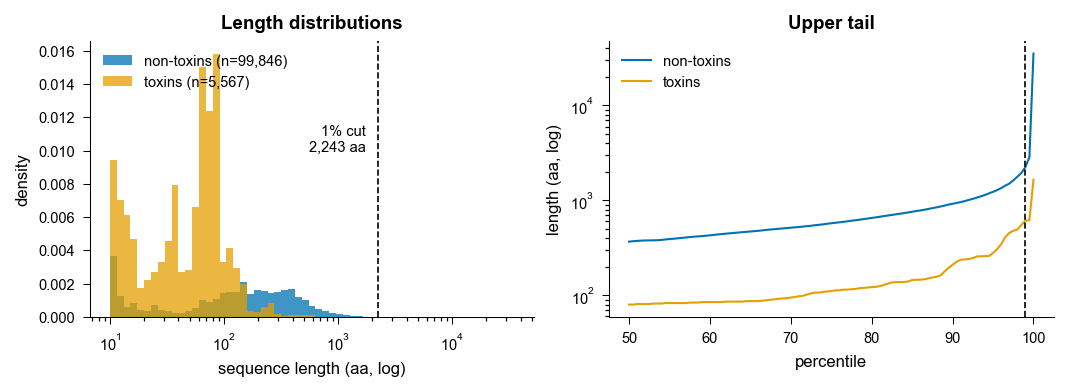


**Verdict on decision 4: defensible but mis-stated.** The cut removes
996 non-toxin *sequences* (1%) carrying
**7.2% of the total residue mass**, while the median
non-toxin length moves only from 368 to
365 aa -- it trims a heavy tail without reshaping the
negative class. The longest toxin (1,652 aa) sits below the threshold, so the cut
is one-sided, but that is a post-hoc check rather than a justification: the threshold was
chosen first. A cleaner framing for the manuscript is *"a 2,243 aa length ceiling,
which excludes 1% of non-toxins and no toxins"* -- stating the ceiling as the decision
rather than the percentile.


In [3]:
tox, nt = R["tox"], R["nt"]
lt = tox["Sequence"].str.len()
# The pre-cut non-toxin lengths, which the audit result does not carry (it returns the
# frame after the cut) -- read here purely to draw the distribution the cut acts on.
ln = pd.read_csv(raw_dir() / "nontox.tsv", sep="\t", usecols=["Sequence"])["Sequence"].str.len()
cutoff = f["length_cutoff"]

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.5), layout="constrained")
bins = np.logspace(1, np.log10(max(lt.max(), ln.max())), 60)
axes[0].hist(ln, bins=bins, color=C_NONTOX, alpha=0.75, density=True,
             label=f"non-toxins (n={len(ln):,})")
axes[0].hist(lt, bins=bins, color=C_TOX, alpha=0.75, density=True,
             label=f"toxins (n={len(lt):,})")
axes[0].axvline(cutoff, color="k", ls="--", lw=0.8)
axes[0].annotate(f"1% cut\n{cutoff:,} aa", (cutoff, axes[0].get_ylim()[1] * 0.6),
                 xytext=(-6, 0), textcoords="offset points", ha="right", fontsize=7)
axes[0].set_xscale("log")
axes[0].set_xlabel("sequence length (aa, log)")
axes[0].set_ylabel("density")
axes[0].set_title("Length distributions")
axes[0].legend(loc="upper left")

q = np.arange(50, 100.01, 0.5)
axes[1].plot(q, np.percentile(ln, q), color=C_NONTOX, label="non-toxins")
axes[1].plot(q, np.percentile(lt, q), color=C_TOX, label="toxins")
axes[1].axvline(99, color="k", ls="--", lw=0.8)
axes[1].set_yscale("log")
axes[1].set_xlabel("percentile")
axes[1].set_ylabel("length (aa, log)")
axes[1].set_title("Upper tail")
axes[1].legend(loc="upper left")
plt.show()

Markdown(f'''
**Verdict on decision 4: defensible but mis-stated.** The cut removes
{f['length_n_removed']:,} non-toxin *sequences* (1%) carrying
**{f['length_residue_mass_removed']:.1%} of the total residue mass**, while the median
non-toxin length moves only from {f['length_median_before']:.0f} to
{f['length_median_after']:.0f} aa -- it trims a heavy tail without reshaping the
negative class. The longest toxin ({lt.max():,} aa) sits below the threshold, so the cut
is one-sided, but that is a post-hoc check rather than a justification: the threshold was
chosen first. A cleaner framing for the manuscript is *"a {cutoff:,} aa length ceiling,
which excludes 1% of non-toxins and no toxins"* -- stating the ceiling as the decision
rather than the percentile.
''')

## 2. Decision 1 -- why *lean* (90%) redundancy reduction?

The pipeline clusters at `min_seq_id=0.9` and keeps one representative per cluster. That
is deliberately mild: homology-partitioned benchmarks in protein ML typically cluster at
30-50% to force train and test apart.

The manuscript's defence is that 90% *"removes near-duplicates while preserving the
substantial intra-family sequence diversity characteristic of toxin families."* Below,
that sentence is turned into two measurements: what 90% actually removed (SS2.1), and
what a stricter threshold would cost (SS2.2 -- the real argument for leanness).

> **`other` is not a family.** `normalize_protein_families` collapses sub-10-member
> families into an `other` bucket *before* clustering, so the clustering cache contains a
> literal `other/` directory that is one of the largest buckets by membership. It is
> excluded from every family count below; counting it inflates the family statistics and
> puts a pseudo-class inside the five largest families.

In [4]:
stats = R["stats"]
lanes, conc = N["lanes"], N["redundancy"]

display(
    pd.DataFrame(lanes).T[["families", "members", "clusters", "removed_frac"]]
    .style.format({"removed_frac": "{:.1%}", "members": "{:,}", "clusters": "{:,}"})
    .set_caption("Clustering at 90%, by lane (`other` shown separately, not as a family)")
)

fam = stats[stats["is_family"] & (stats["family"] != NONTOX_LABEL)]
display(
    fam.nlargest(10, "reduction")[["family", "members", "clusters", "reduction"]]
    .style.format({"reduction": "{:.1%}"}).hide(axis="index")
    .set_caption("Most redundant toxin families at 90%")
)

Markdown(f'''
The two lanes are removed at a similar *rate* ({lanes['toxin']['removed_frac']:.1%} of
toxins, {lanes['nontox']['removed_frac']:.1%} of non-toxins), so redundancy reduction is
**not** a toxin-side correction. The structure is *within* the toxin lane: across the
**{conc['n_families']}** real toxin families, per-family removal has a median of
{conc['median_reduction']:.1%}, the **{conc['top_n']} largest families supply
{conc['top_n_share']:.0%}** of all {conc['total_removed']:,} toxin sequences removed, and
**{conc['zero_redundancy']} families lose nothing at all** because no two of their
members are even 90% identical.
''')

,families,members,clusters,removed_frac
toxin,44.000000,"5,209.0","3,132.0",39.9%
other,1.000000,358.0,284.0,20.7%
nontox,1.000000,"98,850.0","61,763.0",37.5%


family,members,clusters,reduction
Venom_protein_11_family,23,4,82.6%
NGF-beta_family,34,8,76.5%
AVIT__prokineticin__family,21,5,76.2%
Ergtoxin_family,29,9,69.0%
Crotamine-myotoxin_family,15,5,66.7%
Melittin_family,10,4,60.0%
True_venom_lectin_family,10,4,60.0%
Neurotoxin_family,962,399,58.5%
Sea_anemone_sodium_channel_inhibitory_toxin_family,80,35,56.2%
Flavin_monoamine_oxidase_family,25,12,52.0%



The two lanes are removed at a similar *rate* (39.9% of
toxins, 37.5% of non-toxins), so redundancy reduction is
**not** a toxin-side correction. The structure is *within* the toxin lane: across the
**44** real toxin families, per-family removal has a median of
34.0%, the **5 largest families supply
65%** of all 2,077 toxin sequences removed, and
**4 families lose nothing at all** because no two of their
members are even 90% identical.


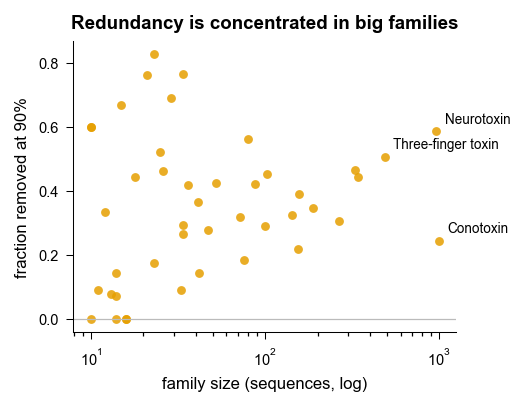

In [5]:
fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.6), layout="constrained")
ax.scatter(fam["members"], fam["reduction"], s=18, color=C_TOX, alpha=0.85, linewidths=0)
ax.set_xscale("log")
ax.set_xlabel("family size (sequences, log)")
ax.set_ylabel(f"fraction removed at {PIPELINE_MIN_SEQ_ID:.0%}")
ax.set_title("Redundancy is concentrated in big families")
ax.axhline(0, color=C_GREY, lw=0.6)
for _, r in fam.nlargest(3, "members").iterrows():
    ax.annotate(r["family"].replace("_family", "").replace("_", " ")[:18],
                (r["members"], r["reduction"]), xytext=(4, 4),
                textcoords="offset points", fontsize=6.5)
plt.show()

This is the fact the whole leanness argument rests on. Redundancy in the toxin lane is
**concentrated**: a handful of large, heavily-sequenced families supply most of the
removed sequences, while many small families contain no two sequences even 90% identical
-- clustering removes nothing from them because there is nothing near-duplicate to
remove.

So the identity threshold does not act uniformly. Lowering it barely touches the
redundant families' *genuine* diversity but cuts directly into the small families that
were already diverse -- and those are precisely the families sitting near the
representative floor. SS2.2 measures that.

### 2.2 The threshold ladder -- what leanness buys

Re-cluster every toxin family at a ladder of identity thresholds, reusing the pipeline's
own per-family input FASTAs (post-SignalP6, pre-clustering) so only `min_seq_id` varies.
The pipeline's own cutoff is read from the clustering cache rather than recomputed, so
the ladder agrees with SS2.1 by construction.

The number that matters is not how many representatives survive, but **how many families
stay above the representative floor** -- families that fall below it are dissolved into
`other` and disappear from the label space. Redundancy reduction and the class vocabulary
are coupled.

threshold,toxin_reps,families_kept,seqs_into_other,families_dissolved,pct_of_pipeline
0.300000,833,16,118,28,27%
0.500000,"1,115",22,107,22,36%
0.700000,"1,868",30,58,14,60%
0.900000,"3,132",36,47,8,100%
1.000000,"4,838",43,7,1,154%


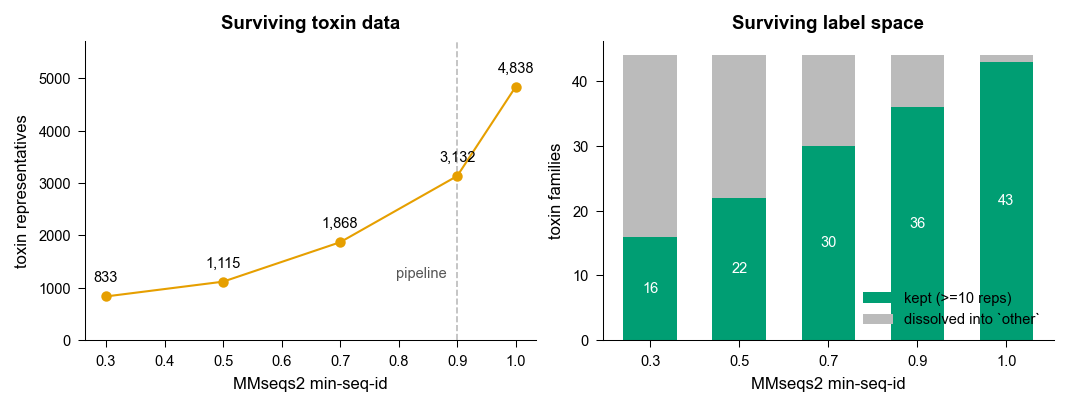


**Verdict on decision 1: justified, but not by the reason the manuscript gives.** The
real argument is the right-hand panel. At the pipeline's 0.9,
**36 toxin families** hold at least 10 representatives
and survive as prediction targets. At 0.3 -- the conventional
homology-partition setting -- only **16** do, and toxin
representatives fall from 3,132 to **833**
(-73%). Identity-based clustering does not
distinguish "near-duplicate" from "small family", so a stricter threshold does not just
shrink the training data -- **it deletes
20 of the classes the model is being
asked to predict.**

Two caveats worth stating in the manuscript rather than leaving for a reviewer to find:

1. **The parameterisation is unreported.** Only `--min-seq-id 0.9` is stated.
   `easy_cluster` also applies a default coverage of 0.8 with `--cov-mode 0` and a greedy
   set-cover cluster mode; two different `-c` values give materially different
   representative sets at the same identity. Cite the full command.
2. **Leanness has a cost, and it is measured in SS6** -- 90% is a ceiling *within* each
   family's clusters, not a homology partition between train and test.


In [6]:
summary = R["summary"]
display(
    summary.assign(pct_of_pipeline=lambda d: d["toxin_reps"]
                   / d.loc[np.isclose(d["threshold"], PIPELINE_MIN_SEQ_ID), "toxin_reps"].iloc[0])
    .style.format({"pct_of_pipeline": "{:.0%}", "toxin_reps": "{:,.0f}"}).hide(axis="index")
    .set_caption(f"Toxin lane, real families only, floor = {MIN_MEMBERS} representatives")
)

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.6), layout="constrained")
ax = axes[0]
ax.plot(summary["threshold"], summary["toxin_reps"], "o-", color=C_TOX)
for _, r in summary.iterrows():
    ax.annotate(f"{int(r['toxin_reps']):,}", (r["threshold"], r["toxin_reps"]),
                textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7)
ax.axvline(PIPELINE_MIN_SEQ_ID, color=C_GREY, ls="--", lw=0.8, zorder=0)
ax.annotate("pipeline", (PIPELINE_MIN_SEQ_ID, ax.get_ylim()[0]), xytext=(-5, 14),
            textcoords="offset points", ha="right", fontsize=7, color="#555")
ax.set_xlabel("MMseqs2 min-seq-id")
ax.set_ylabel("toxin representatives")
ax.set_title("Surviving toxin data")
ax.set_ylim(0, summary["toxin_reps"].max() * 1.18)

ax = axes[1]
x = summary["threshold"].astype(str)
ax.bar(x, summary["families_kept"], color=C_ACCENT, width=0.6,
       label=f"kept (>={MIN_MEMBERS} reps)")
ax.bar(x, summary["families_dissolved"], bottom=summary["families_kept"],
       color=C_GREY, width=0.6, label="dissolved into `other`")
for i, r in summary.reset_index(drop=True).iterrows():
    ax.text(i, r["families_kept"] / 2, str(int(r["families_kept"])), ha="center",
            va="center", fontsize=7, color="white")
ax.set_xlabel("MMseqs2 min-seq-id")
ax.set_ylabel("toxin families")
ax.set_title("Surviving label space")
ax.legend(loc="lower right")
plt.show()

lo = summary.iloc[0]
hi = summary[np.isclose(summary["threshold"], PIPELINE_MIN_SEQ_ID)].iloc[0]
Markdown(f'''
**Verdict on decision 1: justified, but not by the reason the manuscript gives.** The
real argument is the right-hand panel. At the pipeline's {PIPELINE_MIN_SEQ_ID:.1f},
**{int(hi['families_kept'])} toxin families** hold at least {MIN_MEMBERS} representatives
and survive as prediction targets. At {lo['threshold']:.1f} -- the conventional
homology-partition setting -- only **{int(lo['families_kept'])}** do, and toxin
representatives fall from {int(hi['toxin_reps']):,} to **{int(lo['toxin_reps']):,}**
({lo['toxin_reps'] / hi['toxin_reps'] - 1:+.0%}). Identity-based clustering does not
distinguish "near-duplicate" from "small family", so a stricter threshold does not just
shrink the training data -- **it deletes
{int(hi['families_kept']) - int(lo['families_kept'])} of the classes the model is being
asked to predict.**

Two caveats worth stating in the manuscript rather than leaving for a reviewer to find:

1. **The parameterisation is unreported.** Only `--min-seq-id 0.9` is stated.
   `easy_cluster` also applies a default coverage of 0.8 with `--cov-mode 0` and a greedy
   set-cover cluster mode; two different `-c` values give materially different
   representative sets at the same identity. Cite the full command.
2. **Leanness has a cost, and it is measured in SS6** -- 90% is a ceiling *within* each
   family's clusters, not a homology partition between train and test.
''')

## 3. Decision 2 -- clustering is *per-family*, so the toxic/non-toxic boundary is never deduplicated

`cluster_per_family_and_collect` groups by `Protein families` and runs MMseqs2
**separately inside each group**. Every non-toxin has already had its family label
overwritten with the literal string `nontox`, so the partition is:

```
  Phospholipase family   -> its own MMseqs2 run   (toxins only)
  Three-finger toxin ... -> its own MMseqs2 run   (toxins only)
  ...
  nontox                 -> ONE MMseqs2 run       (all non-toxins)
```

A toxin and a 99%-identical non-toxin therefore **never enter the same clustering run**.
The 90% ceiling cannot see the pair, and both survive as representatives -- free to land
on opposite sides of the train/test split, or in the same training batch with opposite
binary labels.

This is a structural property of the design, not a bug: cross-boundary deduplication
would mean deleting one member of each toxin/non-toxin homolog pair, which would silently
decide the very question the classifier is being asked. But it is unstated in the
manuscript and fully unquantified -- SS4 and SS5 quantify it.

### 3.1 Which family names occur on *both* sides of the keyword?

Before overwriting, the raw non-toxin TSV still carries real UniProt family strings. Any
family present in both files is a scaffold that has been recruited into venom while
retaining non-venom members -- exactly the convergent-recruitment story the Discussion
tells rhetorically.

In [7]:
shared = R["shared"]
sf = N["shared_families"]

display(shared.head(10).style.hide(axis="index")
        .set_caption("Shared family strings, by toxin-side membership"))
display(shared.sort_values("smaller_side", ascending=False).head(8).style.hide(axis="index")
        .set_caption("The same table ranked by the SMALLER side -- viable two-sided case studies"))

top_tox = shared.iloc[0]
top_bal = shared.sort_values("smaller_side", ascending=False).iloc[0]
Markdown(f'''
**{sf['n_shared']} family strings occur on both sides of KW-0800**, covering
**{sf['toxins_in_shared']:,} toxins ({sf['toxin_share']:.0%} of all family-annotated
toxins)**. That is a lower bound: **{sf['nt_without_family']:,} non-toxins carry no family
annotation at all** and cannot appear in the table.

The two rankings say different things, and the second is the one that matters. Ranked by
toxin count the table is led by *{top_tox['family']}* ({int(top_tox['toxins'])} toxins but
only {int(top_tox['non_toxins'])} non-toxins) -- there is nothing to compare across the
boundary. Ranked by the smaller side, **{top_bal['family']}** stands out at
{int(top_bal['toxins'])} toxins and {int(top_bal['non_toxins'])} non-toxins: substantial
in both directions at once. That is why phospholipase is the case study in SS4 -- it is
the largest scaffold genuinely *bisected* by the keyword rather than sitting almost
entirely on one side of it.
''')

family,toxins,non_toxins,smaller_side
Three-finger toxin family,485,4,4
Long (4 C-C) scorpion toxin superfamily,341,5,5
Phospholipase A2 family,298,145,145
Neurotoxin 10 (Hwtx-1) family,286,1,1
Short scorpion toxin superfamily,266,6,6
Venom metalloproteinase (M12B) family,188,4,4
Neurotoxin 19 (CSTX) family,182,1,1
Conotoxin M superfamily,158,1,1
Peptidase S1 family,156,604,156
Conotoxin A superfamily,146,2,2


family,toxins,non_toxins,smaller_side
Peptidase S1 family,156,604,156
Phospholipase A2 family,298,145,145
Venom Kunitz-type family,102,148,102
CRISP family,52,79,52
NGF-beta family,34,49,34
Non-disulfide-bridged peptide (NDBP) superfamily,33,138,33
Natriuretic peptide family,33,54,33
Insulin family,26,231,26



**85 family strings occur on both sides of KW-0800**, covering
**3,892 toxins (70% of all family-annotated
toxins)**. That is a lower bound: **20,118 non-toxins carry no family
annotation at all** and cannot appear in the table.

The two rankings say different things, and the second is the one that matters. Ranked by
toxin count the table is led by *Three-finger toxin family* (485 toxins but
only 4 non-toxins) -- there is nothing to compare across the
boundary. Ranked by the smaller side, **Peptidase S1 family** stands out at
156 toxins and 604 non-toxins: substantial
in both directions at once. That is why phospholipase is the case study in SS4 -- it is
the largest scaffold genuinely *bisected* by the keyword rather than sitting almost
entirely on one side of it.


## 4. The phospholipase case study

Phospholipase A2 is the textbook convergent-recruitment scaffold: the same ~120-residue
fold serves as a digestive/physiological enzyme in most animals *and* as a principal venom
component in snakes, bees and scorpions. Swiss-Prot's KW-0800 assignment therefore cuts
**through** the family rather than around it.

Two cohorts are reported below, because they answer different questions and only one of
them is "phospholipase A2":

- the **strict PLA2** cohort (first-listed family begins `Phospholipase A2 family`), and
- a looser **phospholipase-related** cohort (substring match), which also collects
  phospholipase B/D and the alpha-type PLA2 *inhibitor* family.

Sequence-identity claims are safe under either cohort -- a non-homologous family simply
returns no hit -- but a count quoted as "phospholipase A2" must use the strict one.

In [8]:
p = N["phospholipase"]
display(pd.DataFrame([
    {"cohort": "strict PLA2", "toxin-side": p["strict_tox"], "non-toxin-side": p["strict_nt"]},
    {"cohort": "phospholipase-related (substring)", "toxin-side": p["loose_tox"],
     "non-toxin-side": p["loose_nt"]},
]).set_index("cohort").style.set_caption("Two phospholipase cohorts"))

pla_best = R["pla_best"]
display(identity_ladder(pla_best["fident"], n_total=p["loose_nt"], label="non-toxin PLAs",
                        thresholds=(0.95, 0.90, 0.80, 0.70, 0.50))
        .style.hide(axis="index")
        .set_caption(f"Closest venom relative of each non-toxin phospholipase "
                     f"(coverage >= {DUP_COV:.0%})"))

Markdown(
    f"**{p['nt_with_venom_homolog']} of {p['loose_nt']}** non-toxin phospholipases have a "
    f"venom homologue at >= {DUP_COV:.0%} alignment coverage, and **{p['twins']} are "
    f">= {DUP_IDENT:.0%} identical to a venom toxin** over >= {DUP_COV:.0%} of their length."
)

,toxin-side,non-toxin-side
cohort,,
strict PLA2,298,145
phospholipase-related (substring),327,213


identity >=,non-toxin PLAs,% of non-toxin PLAs
95%,15,7.0%
90%,23,10.8%
80%,45,21.1%
70%,84,39.4%
50%,114,53.5%


**134 of 213** non-toxin phospholipases have a venom homologue at >= 80% alignment coverage, and **23 are >= 90% identical to a venom toxin** over >= 80% of their length.

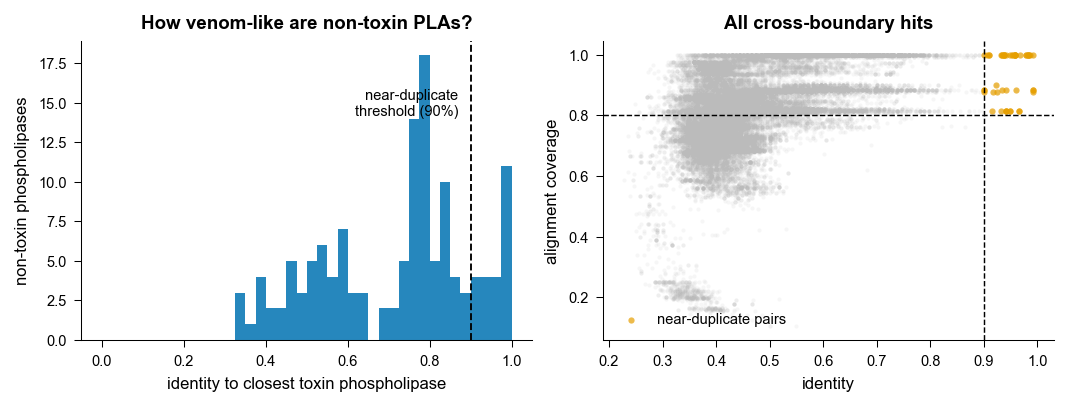

In [9]:
pla_hits = R["pla_hits"]
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.6), layout="constrained")
ax = axes[0]
ax.hist(pla_best["fident"], bins=np.arange(0, 1.02, 0.025), color=C_NONTOX, alpha=0.85)
ax.axvline(DUP_IDENT, color="k", ls="--", lw=0.9)
ax.annotate(f"near-duplicate\nthreshold ({DUP_IDENT:.0%})",
            (DUP_IDENT, ax.get_ylim()[1] * 0.75), xytext=(-6, 0),
            textcoords="offset points", ha="right", fontsize=7)
ax.set_xlabel("identity to closest toxin phospholipase")
ax.set_ylabel("non-toxin phospholipases")
ax.set_title("How venom-like are non-toxin PLAs?")

ax = axes[1]
ax.scatter(pla_hits["fident"], pla_hits["alncov"], s=4, alpha=0.12, color=C_GREY, linewidths=0)
dup = pla_hits[(pla_hits["fident"] >= DUP_IDENT) & (pla_hits["alncov"] >= DUP_COV)]
ax.scatter(dup["fident"], dup["alncov"], s=9, alpha=0.7, color=C_TOX, linewidths=0,
           label="near-duplicate pairs")
ax.axvline(DUP_IDENT, color="k", ls="--", lw=0.7)
ax.axhline(DUP_COV, color="k", ls="--", lw=0.7)
ax.set_xlabel("identity")
ax.set_ylabel("alignment coverage")
ax.set_title("All cross-boundary hits")
ax.legend(loc="lower left")
plt.show()

### 4.1 Where do the twins end up?

A twin pair only matters if both members survive clustering and enter the model. Check
them against the representative set and the git-tracked split manifest.

Leakage is counted **in both directions**: a *test* toxin whose non-toxin twin is in
training leaks exactly as much as the reverse, and reporting only one direction
understates the count.

In [10]:
twins = R["twins"]
both_rep = twins.dropna(subset=["tox_split", "nt_split"])
display(pd.crosstab(both_rep["tox_split"], both_rep["nt_split"], dropna=False)
        .rename_axis(index="toxin in", columns="non-toxin twin in"))

Markdown(f'''
Of the **{p['twins']}** twin pairs, **{p['twin_n_pairs']} had both members survive
clustering**. Of those, **{p['twin_different_split']} were assigned to different splits**
({p['twin_same_split']} to the same one), and **{p['twin_cross_train_eval']} straddle
train and val/test** -- {p['twin_toxin_train_nontoxin_eval']} with the toxin in train and
its non-toxin twin in val/test, plus {p['twin_toxin_eval_nontoxin_train']} in the
opposite direction. No sequence-based model can separate such a pair; the residual error
is a property of the *label*, not of the model.

**Verdict on decisions 2 + 3.** Both hold up as *choices*, but each needs a sentence of
acknowledgement in the manuscript. Per-family clustering means the 90% ceiling is enforced
**within** classes and never **between** them, so near-identical toxin/non-toxin pairs
survive by construction -- the design is right, because deduplicating across the boundary
would amount to deciding by fiat which member of each pair is "really" a toxin, but it
should be stated rather than left implicit. And the keyword-derived negative set contains
proteins that are, at the sequence level, venom phospholipases: where such a pair straddles
train and test, the residual error is a **label** property. This is the quantitative
backing for the Discussion's claim that confident "false positives" on recruited scaffolds
can reflect curation gaps rather than model error.
''')

non-toxin twin in,test,train,val
toxin in,,,
test,1,2,0
train,2,5,1



Of the **23** twin pairs, **11 had both members survive
clustering**. Of those, **5 were assigned to different splits**
(6 to the same one), and **5 straddle
train and val/test** -- 3 with the toxin in train and
its non-toxin twin in val/test, plus 2 in the
opposite direction. No sequence-based model can separate such a pair; the residual error
is a property of the *label*, not of the model.

**Verdict on decisions 2 + 3.** Both hold up as *choices*, but each needs a sentence of
acknowledgement in the manuscript. Per-family clustering means the 90% ceiling is enforced
**within** classes and never **between** them, so near-identical toxin/non-toxin pairs
survive by construction -- the design is right, because deduplicating across the boundary
would amount to deciding by fiat which member of each pair is "really" a toxin, but it
should be stated rather than left implicit. And the keyword-derived negative set contains
proteins that are, at the sequence level, venom phospholipases: where such a pair straddles
train and test, the residual error is a **label** property. This is the quantitative
backing for the Discussion's claim that confident "false positives" on recruited scaffolds
can reflect curation gaps rather than model error.


## 5. How similar are toxins and non-toxins in general?

Phospholipases are the clearest case, but are they exceptional? Search **every toxin
representative against every representative** -- i.e. the actual model inputs, after all
preprocessing.

Two different questions are answered from that one search, and conflating them is the
easiest mistake to make here:

1. **Does a non-toxin homologue exist?** -- a statement about the neighbourhood.
2. **Is the *nearest* neighbour a non-toxin?** -- a statement about what best-hit
   annotation transfer actually does.

A toxin with a 50%-identical non-toxin relative and a 95%-identical toxin relative is
still labelled correctly by 1-NN, so only the second quantity bounds a homology baseline.

> **The search uses `toxfam.evaluation.hbi`'s own parameters** (`s=9.0`, no E-value
> cutoff, `max_seqs=1000`, best hit by minimum E-value, no coverage floor). That matters:
> imposing this notebook's coverage floor selects a *different protein* as the neighbour
> and understates the transfer-error floor by roughly a factor of 1.7. A number that
> claims to bound a baseline must be measured with that baseline's parameters.

In [11]:
nnb = N["nearest_neighbour"]
glob_best, nn = R["glob_best"], R["nn"]
n_tox_rep = nnb["n_toxin_reps"]

display(identity_ladder(glob_best["fident"], n_total=n_tox_rep, label="toxin reps")
        .style.hide(axis="index")
        .set_caption(f"Each toxin representative's closest NON-TOXIN relative "
                     f"(coverage >= {DUP_COV:.0%})"))

sub = nn[nn["nn_is_nontox"]]
Markdown(f'''
| quantity | count | share |
|---|---|---|
| toxin representatives | {n_tox_rep:,} | 100% |
| ...with a non-toxin homologue (coverage >= {DUP_COV:.0%}) | {nnb['with_nontoxin_homolog']:,} | {nnb['with_nontoxin_homolog_frac']:.1%} |
| ...whose **nearest neighbour of all** is a non-toxin | **{nnb['nearest_is_nontoxin']:,}** | **{nnb['nearest_is_nontoxin_frac']:.1%}** |

The second number is the floor on 1-NN homology transfer: those toxins are labelled
non-toxic by any method that copies its best hit's annotation.
''')

identity >=,toxin reps,% of toxin reps
90%,56,1.6%
80%,132,3.9%
70%,251,7.3%
50%,659,19.3%
30%,1331,39.0%



| quantity | count | share |
|---|---|---|
| toxin representatives | 3,416 | 100% |
| ...with a non-toxin homologue (coverage >= 80%) | 1,446 | 42.3% |
| ...whose **nearest neighbour of all** is a non-toxin | **300** | **8.8%** |

The second number is the floor on 1-NN homology transfer: those toxins are labelled
non-toxic by any method that copies its best hit's annotation.


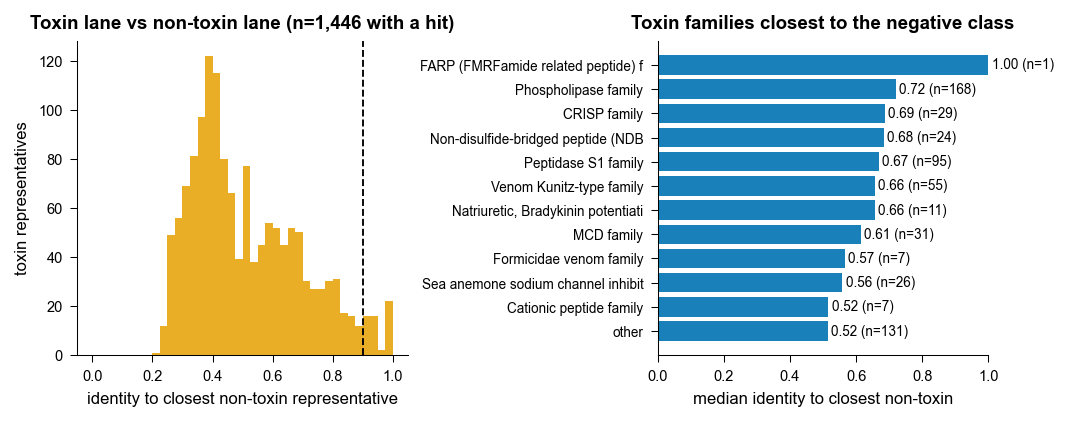

,n_with_hit,median_id,max_id,n_reps,pct_with_hit
family,,,,,
FARP (FMRFamide related peptide) family,1,1.000,1.000,12,8%
Phospholipase family,168,0.721,1.000,175,96%
CRISP family,29,0.687,0.994,30,97%
Non-disulfide-bridged peptide (NDBP) superfamily,24,0.684,1.000,30,80%
Peptidase S1 family,95,0.669,0.934,95,100%
Venom Kunitz-type family,55,0.657,1.000,56,98%
"Natriuretic, Bradykinin potentiating peptide family",11,0.657,1.000,71,15%
MCD family,31,0.615,0.965,62,50%
Formicidae venom family,7,0.567,0.730,36,19%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.7), layout="constrained")
ax = axes[0]
ax.hist(glob_best["fident"], bins=np.arange(0, 1.02, 0.025), color=C_TOX, alpha=0.85)
ax.axvline(DUP_IDENT, color="k", ls="--", lw=0.9)
ax.set_xlabel("identity to closest non-toxin representative")
ax.set_ylabel("toxin representatives")
ax.set_title(f"Toxin lane vs non-toxin lane (n={len(glob_best):,} with a hit)")

fam_of = R["fam_of"]
gb = glob_best.assign(family=glob_best["query"].map(fam_of))
n_reps = fam_of.value_counts()
byfam = (gb.groupby("family")
         .agg(n_with_hit=("fident", "size"), median_id=("fident", "median"),
              max_id=("fident", "max"))
         .join(n_reps.rename("n_reps"))
         .assign(pct_with_hit=lambda d: d["n_with_hit"] / d["n_reps"])
         .sort_values("median_id", ascending=False))
byfam = byfam[byfam.index.map(lambda x: x != NONTOX_LABEL)]
top = byfam.head(12).iloc[::-1]
ax = axes[1]
ax.barh(range(len(top)), top["median_id"], color=C_NONTOX, alpha=0.9)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([s[:34] for s in top.index], fontsize=6.5)
ax.set_xlabel("median identity to closest non-toxin")
ax.set_xlim(0, 1)
ax.set_title("Toxin families closest to the negative class")
for i, (v, n) in enumerate(zip(top["median_id"], top["n_with_hit"])):
    ax.text(v + 0.01, i, f"{v:.2f} (n={int(n)})", va="center", fontsize=6.5)
plt.show()

display(byfam.head(12).style
        .format({"median_id": "{:.3f}", "max_id": "{:.3f}", "pct_with_hit": "{:.0%}"})
        .set_caption("Toxin families whose members most resemble non-toxins"))

In [13]:
Markdown(f'''
**The nearest-neighbour number is the one to quote.** It is a hard floor: those
{nnb['nearest_is_nontoxin']:,} toxins ({nnb['nearest_is_nontoxin_frac']:.1%}) are assigned a
non-toxin label by *any* method that transfers its best hit's annotation, because the
nearest thing in sequence space genuinely is not a toxin. The
{nnb['with_nontoxin_homolog_frac']:.0%} figure says only that a non-toxin relative exists
somewhere, which is a much weaker statement.

A learned representation is not obliged to make the same call, since it can weigh features
the best-hit rule discards. That is the defensible form of the argument for the ToxFam
design: **the toxic/non-toxic boundary does not coincide with the homology boundary**, so
homology transfer has an irreducible error floor that a learned model can get under. It is
also why per-family clustering must not be replaced by global clustering -- global
clustering would silently delete exactly these informative pairs.

The families at the top of the right-hand panel are precisely the ones the Discussion names
as convergently recruited from physiological scaffolds -- now with numbers instead of
assertion.
''')


**The nearest-neighbour number is the one to quote.** It is a hard floor: those
300 toxins (8.8%) are assigned a
non-toxin label by *any* method that transfers its best hit's annotation, because the
nearest thing in sequence space genuinely is not a toxin. The
42% figure says only that a non-toxin relative exists
somewhere, which is a much weaker statement.

A learned representation is not obliged to make the same call, since it can weigh features
the best-hit rule discards. That is the defensible form of the argument for the ToxFam
design: **the toxic/non-toxic boundary does not coincide with the homology boundary**, so
homology transfer has an irreducible error floor that a learned model can get under. It is
also why per-family clustering must not be replaced by global clustering -- global
clustering would silently delete exactly these informative pairs.

The families at the top of the right-hand panel are precisely the ones the Discussion names
as convergently recruited from physiological scaffolds -- now with numbers instead of
assertion.


## 6. The cost of leanness: residual train-test homology

Leanness is not free, and the manuscript already concedes the mechanism --
*"the identity ceiling is enforced only among the retained representatives, [so] this is
redundancy reduction rather than a strict homology-based partition."* Splits are drawn by
stratified random sampling **after** clustering, so nothing stops a test representative
from having an 89%-identical training neighbour. Measure it directly.

,n,no hit,90%-100%,70%-90%,50%-70%,0%-50%
subset,,,,,,
all test reps,9779,1867,30,4777,1924,1181
toxin test reps,515,114,8,245,102,46
non-toxin test reps,9264,1753,22,4532,1822,1135


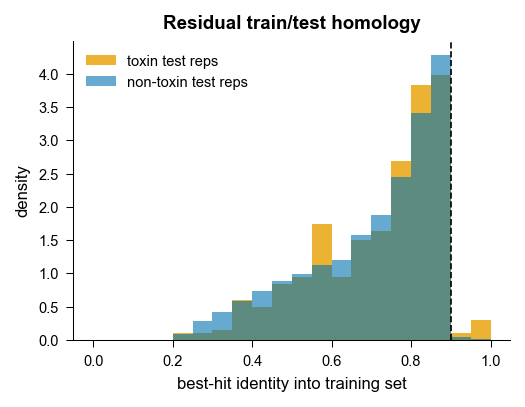

**253 of 515 toxin test representatives (49%)** have a >= 70% identical training neighbour; only 8 exceed 90%.

In [14]:
tt_best, reps = R["tt_best"], R["reps"]
tth = N["train_test_homology"]
test_ids = set(reps.loc[reps["Split"] == "test", "identifier"])
n_tox_test = tth["n_toxin_test"]

rows = [
    homology_band_table(tt_best, subset_label="all test reps", n_total=len(test_ids)),
    homology_band_table(tt_best[tt_best["family"] != NONTOX_LABEL],
                        subset_label="toxin test reps", n_total=n_tox_test),
    homology_band_table(tt_best[tt_best["family"] == NONTOX_LABEL],
                        subset_label="non-toxin test reps",
                        n_total=len(test_ids) - n_tox_test),
]
display(pd.DataFrame(rows).set_index("subset").style
        .set_caption("Best-hit identity from each TEST representative into the TRAINING set"))

fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.6), layout="constrained")
bins = np.arange(0, 1.02, 0.05)
ax.hist(tt_best[tt_best["family"] != NONTOX_LABEL]["fident"], bins=bins, color=C_TOX,
        alpha=0.8, density=True, label="toxin test reps")
ax.hist(tt_best[tt_best["family"] == NONTOX_LABEL]["fident"], bins=bins, color=C_NONTOX,
        alpha=0.6, density=True, label="non-toxin test reps")
ax.axvline(DUP_IDENT, color="k", ls="--", lw=0.8)
ax.set_xlabel("best-hit identity into training set")
ax.set_ylabel("density")
ax.set_title("Residual train/test homology")
ax.legend()
plt.show()

Markdown(
    f"**{tth['ge70']} of {n_tox_test} toxin test representatives "
    f"({tth['ge70_frac']:.0%})** have a >= 70% identical training neighbour; only "
    f"{tth['ge90']} exceed 90%."
)

### 6.1 Where does the residual >=90% leakage come from?

Very few test representatives have a >=90% identical training neighbour, but many have a
50-90% one. The natural expectation is that the few remaining >=90% pairs must be
**cross-family** -- two representatives of the same family passed through the same
clustering run, so they "should" already be below 90% of each other, whereas per-family
clustering can never see a cross-family pair (SS3). Worth testing rather than assuming.

In [15]:
hi_pairs = R["hi_pairs"]
display(hi_pairs[hi_pairs["cross_family"]]
        [["query", "target", "fident", "alncov", "test_family", "train_family"]]
        .head(10).style.format({"fident": "{:.3f}", "alncov": "{:.2f}"}).hide(axis="index")
        .set_caption("Cross-family near-duplicates spanning train and test"))

xor_tox = int(((hi_pairs["test_family"] == NONTOX_LABEL)
               != (hi_pairs["train_family"] == NONTOX_LABEL)).sum())
Markdown(f'''
**The expectation was half wrong, and the half that failed is the informative one.**

Of the **{tth['n_test_reps_ge90']}** test representatives with a >= {DUP_IDENT:.0%}
identical training neighbour, **{tth['ge90_cross_family']} are cross-family** -- and every
one of them ({xor_tox}) is a toxin-to-non-toxin pair, i.e. precisely the pairs per-family
clustering is structurally incapable of removing. That is decision 2's blind spot showing
up at the train/test boundary, not a new problem.

But **{tth['ge90_same_family']} are same-family**, which the 90% clustering was supposed to
have prevented. It did not, because `easy_cluster` is a greedy set-cover, not a
complete-linkage partition: it guarantees each member is within the threshold *of its own
representative*, not that two representatives of different clusters are below the threshold
*of each other*. Cluster-time coverage (`--cov-mode 0`, bidirectional) also differs from the
coverage measured here (`alnlen / max(qlen, tlen)`), so borderline pairs fall on opposite
sides of the two tests.

Neither effect is large -- {tth['n_test_reps_ge90']} of {len(test_ids):,} test
representatives -- but the second means **the manuscript cannot claim that no train/test
pair exceeds 90% identity.** It should claim what is true: that no member exceeds 90%
identity to its own cluster representative.

**Verdict.** This is the honest cost of decision 1. Near-duplicate train/test pairs are
rare; what remains is a broad band of 50-90% train/test similarity -- real homology, not
duplication. The consequence is one of framing: headline family-classification metrics are
**not** a measure of remote-homology generalisation -- they measure performance on a
realistic, redundancy-reduced but homology-rich distribution. That framing is defensible and
right for this application (a curator triaging a new Swiss-Prot entry genuinely does
encounter proteins similar to known toxins), but the manuscript should state the identity
distribution above and lean on `non_metazoan` and `unreviewed` as the generalisation
evidence, since neither shares the training distribution.
''')

query,target,fident,alncov,test_family,train_family
P00598,P00597,1.000,0.98,Phospholipase family,nontox
P0DPU1,P0DPV2,0.994,1.00,CRISP family,nontox
Q6ITB9,Q6ITB4,0.983,1.00,Venom Kunitz-type family,nontox
Q6ITB1,B5L5R0,0.983,1.00,Venom Kunitz-type family,nontox
P83082,Q58T40,0.976,1.00,other,nontox
P0DXZ6,I7GQA7,0.949,1.00,Phospholipase family,nontox
A8E2V9,Q92152,0.932,0.98,nontox,Phospholipase family
P0DJ46,P0DJ48,0.932,1.00,nontox,Venom Kunitz-type family
P20249,Q6H3D0,0.925,0.99,nontox,Phospholipase family
P0DPT0,P0DMB4,0.923,0.96,nontox,other



**The expectation was half wrong, and the half that failed is the informative one.**

Of the **30** test representatives with a >= 90%
identical training neighbour, **12 are cross-family** -- and every
one of them (12) is a toxin-to-non-toxin pair, i.e. precisely the pairs per-family
clustering is structurally incapable of removing. That is decision 2's blind spot showing
up at the train/test boundary, not a new problem.

But **18 are same-family**, which the 90% clustering was supposed to
have prevented. It did not, because `easy_cluster` is a greedy set-cover, not a
complete-linkage partition: it guarantees each member is within the threshold *of its own
representative*, not that two representatives of different clusters are below the threshold
*of each other*. Cluster-time coverage (`--cov-mode 0`, bidirectional) also differs from the
coverage measured here (`alnlen / max(qlen, tlen)`), so borderline pairs fall on opposite
sides of the two tests.

Neither effect is large -- 30 of 9,779 test
representatives -- but the second means **the manuscript cannot claim that no train/test
pair exceeds 90% identity.** It should claim what is true: that no member exceeds 90%
identity to its own cluster representative.

**Verdict.** This is the honest cost of decision 1. Near-duplicate train/test pairs are
rare; what remains is a broad band of 50-90% train/test similarity -- real homology, not
duplication. The consequence is one of framing: headline family-classification metrics are
**not** a measure of remote-homology generalisation -- they measure performance on a
realistic, redundancy-reduced but homology-rich distribution. That framing is defensible and
right for this application (a curator triaging a new Swiss-Prot entry genuinely does
encounter proteins similar to known toxins), but the manuscript should state the identity
distribution above and lean on `non_metazoan` and `unreviewed` as the generalisation
evidence, since neither shares the training distribution.


## 7. Decision 6 -- why trim signal peptides at all?

Before clustering, the pipeline runs SignalP6 (`preprocessing.remove_signal_peptides`) and
trims any predicted signal peptide with cleavage probability >0.8 from the N-terminus. The
manuscript justifies this in a single clause -- *"so that all downstream representations
are built from mature sequences"* -- which restates the action rather than giving a reason,
and never defends the 0.8 cutoff.

There are three independent reasons to trim, plus the question of the cutoff itself:

- **7.1** the signal peptide is a far larger share of a toxin than of a non-toxin;
- **7.2** without trimming the data mixes two sequence frames *within* families;
- **7.3** signal-peptide presence is additionally a toxicity shortcut *between* classes;
- **7.4** whether p>0.8 is a defensible operating point at all.

### 7.1 A signal peptide is a quarter of a toxin and a rounding error in a non-toxin

Signal peptides are roughly constant in length (~20-25 aa) regardless of the protein
carrying them. Toxins are short and non-toxins are not, so the *same* absolute prefix
occupies very different fractions of the two classes.

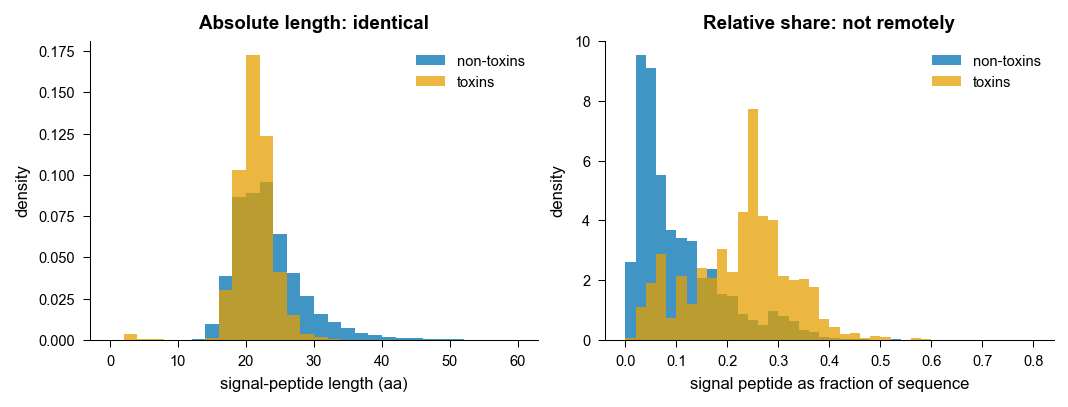


SignalP6 fires on **68% of toxins** against
**17% of non-toxins**. The signal peptide is a median
**24% of a toxin** but only **7% of a non-toxin**.

This alone justifies trimming for a per-protein embedding model. ProtT5 pools over the
whole sequence, so leaving the signal peptide in place means roughly a quarter of the
average toxin's representation encodes a secretion tag. The distortion is not merely
present, it is *class-dependent* -- exactly the kind of asymmetry a classifier will happily
exploit.


In [16]:
sp = N["signal_peptide"]
tox_sp, nt_sp = R["tox_sp"], R["nt_sp"]
t_sp, n_sp = tox_sp[tox_sp["trimmed"]], nt_sp[nt_sp["trimmed"]]

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.6), layout="constrained")
ax = axes[0]
bins = np.arange(0, 61, 2)
ax.hist(n_sp["sp_len"], bins=bins, color=C_NONTOX, alpha=0.75, density=True, label="non-toxins")
ax.hist(t_sp["sp_len"], bins=bins, color=C_TOX, alpha=0.75, density=True, label="toxins")
ax.set_xlabel("signal-peptide length (aa)")
ax.set_ylabel("density")
ax.set_title("Absolute length: identical")
ax.legend()

ax = axes[1]
bins = np.arange(0, 0.81, 0.02)
ax.hist(n_sp["sp_frac"], bins=bins, color=C_NONTOX, alpha=0.75, density=True, label="non-toxins")
ax.hist(t_sp["sp_frac"], bins=bins, color=C_TOX, alpha=0.75, density=True, label="toxins")
ax.set_xlabel("signal peptide as fraction of sequence")
ax.set_ylabel("density")
ax.set_title("Relative share: not remotely")
ax.legend()
plt.show()

Markdown(f'''
SignalP6 fires on **{sp['tox_trim_rate']:.0%} of toxins** against
**{sp['nt_trim_rate']:.0%} of non-toxins**. The signal peptide is a median
**{sp['sp_frac_tox']:.0%} of a toxin** but only **{sp['sp_frac_nt']:.0%} of a non-toxin**.

This alone justifies trimming for a per-protein embedding model. ProtT5 pools over the
whole sequence, so leaving the signal peptide in place means roughly a quarter of the
average toxin's representation encodes a secretion tag. The distortion is not merely
present, it is *class-dependent* -- exactly the kind of asymmetry a classifier will happily
exploit.
''')

### 7.2 The reason we actually trimmed: otherwise the data mixes two sequence frames

A high trim rate means that *without* trimming the training set would contain both kinds of
sequence side by side: some proteins carrying their N-terminal signal peptide, others
(cytosolic ones, or entries already deposited as mature chains) not.

That inconsistency is not spread evenly across the label space, and it is not a
between-class effect like SS7.3 -- it happens **inside individual families**, where two
members of the same class are represented in two different frames.

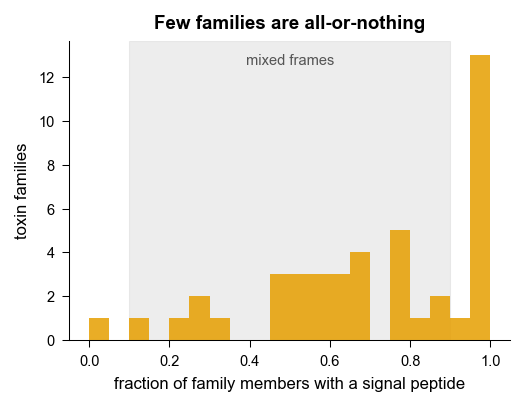

,n,trim_rate
family,,
Conotoxin family,996,78%
Neurotoxin family,962,78%
Three-finger toxin family,485,55%
Long (4 C-C) scorpion toxin superfamily,341,62%
Phospholipase family,327,66%
Short scorpion toxin superfamily,266,51%
Venom metalloproteinase (M12B) family,188,59%
Peptidase S1 family,156,82%
Snaclec family,142,77%


**29 of 44** toxin families with at least 10 members are internally mixed (10-90% of members carrying a signal peptide), covering **90%** of all family-labelled toxins. The heterogeneity is the normal case, not an edge case.

In [17]:
fam_sp = R["fam_sp"]
fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.6), layout="constrained")
ax.hist(fam_sp["trim_rate"], bins=np.arange(0, 1.05, 0.05), color=C_TOX, alpha=0.85)
ax.axvspan(0.10, 0.90, color=C_GREY, alpha=0.25, zorder=0)
ax.annotate("mixed frames", (0.5, ax.get_ylim()[1] * 0.92), ha="center", fontsize=7, color="#555")
ax.set_xlabel("fraction of family members with a signal peptide")
ax.set_ylabel("toxin families")
ax.set_title("Few families are all-or-nothing")
plt.show()

display(fam_sp.loc[fam_sp["mixed"], ["n", "trim_rate"]]
        .sort_values("n", ascending=False).head(10)
        .style.format({"trim_rate": "{:.0%}"})
        .set_caption("Largest mixed families -- both frames present in the same class"))

Markdown(
    f"**{sp['families_mixed']} of {sp['families_total']}** toxin families with at least "
    f"{MIN_MEMBERS} members are internally mixed (10-90% of members carrying a signal "
    f"peptide), covering **{sp['mixed_share']:.0%}** of all family-labelled toxins. "
    f"The heterogeneity is the normal case, not an edge case."
)

Does it do any harm? Start with alignment. Within a mixed family, take the members that
carry a signal peptide and align them against the members that do not, **before** and
**after** trimming.

The comparison is **paired per query** -- each sequence against itself in the two frames.
That distinction is load-bearing: per-family *medians* of these quantities are perfectly
stable while a substantial minority of the individual alignments move, so a
median-of-medians comparison would support a much stronger claim than the data does.

In [18]:
fs = sp["frame_shift"]
display(pd.DataFrame([
    {"quantity": q,
     "queries changed": fs[f"{k}_changed"],
     "share changed": f"{fs[f'{k}_changed_frac']:.1%}",
     "median delta": f"{fs[f'{k}_median_delta']:+.3f}"}
    for q, k in [("alignment length", "alnlen"), ("bit score", "bits"),
                 ("sequence identity", "fident"), ("alignment coverage", "alncov")]
]).set_index("quantity").style.set_caption(
    f"Paired per-query comparison across {fs['n_families']} mixed families "
    f"(n={fs['n_paired']:,} queries)"))

Markdown(f'''
**The medians do not move; a substantial minority of the alignments do.** Median alignment
length, bit score and identity are all unchanged
({fs['alnlen_median_delta']:+.0f}, {fs['bits_median_delta']:+.0f},
{fs['fident_median_delta']:+.3f}) -- but per query, **{fs['bits_changed_frac']:.0%} of bit
scores** and **{fs['alnlen_changed_frac']:.0%} of alignment lengths** change. Coverage moves
for essentially every query ({fs['alncov_changed_frac']:.0%}), and it moves for a mechanical
reason: coverage is `alnlen / max(qlen, tlen)` and trimming shrinks the denominator.

So the honest statement is that the signal peptide is **largely, but not entirely, ignored
by the aligner** -- it has little counterpart in the homolog, so the alignment usually
survives trimming unchanged. It is *not* "provably inert to alignment", and the manuscript
should not say so.
''')

,queries changed,share changed,median delta
quantity,,,
alignment length,271,11.5%,+0.000
bit score,714,30.4%,+0.000
sequence identity,294,12.5%,+0.000
alignment coverage,2348,100.0%,+0.136



**The medians do not move; a substantial minority of the alignments do.** Median alignment
length, bit score and identity are all unchanged
(+0, +0,
+0.000) -- but per query, **30% of bit
scores** and **12% of alignment lengths** change. Coverage moves
for essentially every query (100%), and it moves for a mechanical
reason: coverage is `alnlen / max(qlen, tlen)` and trimming shrinks the denominator.

So the honest statement is that the signal peptide is **largely, but not entirely, ignored
by the aligner** -- it has little counterpart in the homolog, so the alignment usually
survives trimming unchanged. It is *not* "provably inert to alignment", and the manuscript
should not say so.


In [19]:
clust = R["clust"]
spread = sp["clustering_spread"]
display(clust.assign(delta=clust["trimmed"] - clust["untrimmed"]).style
        .set_caption(f"Representatives at min_seq_id={PIPELINE_MIN_SEQ_ID}, "
                     "clustering untrimmed vs trimmed sequences"))

Markdown(f'''
Clustering is close to a wash **in net terms** ({spread['net']:+d} representatives,
{spread['net_frac']:+.1%}) -- but that net is a sum of sizeable cancelling per-family
shifts: {spread['n_up']} families move up, {spread['n_down']} move down, and the mean
absolute per-family shift is {spread['mean_abs_rel']:.1%}, with the worst family moving
{spread['max_rel_decrease']:.1%}. Reporting only the net would overstate how little happens.

**That is what isolates the real reason for trimming.** ProtT5 has no alignment step. It
pools a representation over *every residue it is given*, so it cannot skip a prefix the way
an aligner largely does. Two members of one family are then embedded from inputs differing
by a systematic ~20-residue block present in one and absent in the other -- and per SS7.1
that block is roughly a quarter of a median toxin. Trimming puts every sequence in the same
frame, so within-family variation in the embedding reflects biology rather than whether
UniProt's entry happened to begin at the precursor or the mature chain.

The honest form of the argument is therefore: **the mixed frame matters mostly *because* the
model is embedding-based.** This also predicts that the EAT baseline (1-NN in ProtT5 space)
is more sensitive to trimming than HBI (MMseqs) -- a prediction this notebook does not test,
since it would require re-embedding both variants.
''')

,n,untrimmed,trimmed,delta
Conotoxin family,996,731,753,22
Neurotoxin family,962,394,399,5
Three-finger toxin family,485,258,240,-18
Long (4 C-C) scorpion toxin superfamily,341,220,190,-30
Phospholipase family,327,173,175,2
Short scorpion toxin superfamily,266,197,185,-12
Venom metalloproteinase (M12B) family,188,122,123,1
Peptidase S1 family,156,94,95,1



Clustering is close to a wash **in net terms** (-29 representatives,
-1.3%) -- but that net is a sum of sizeable cancelling per-family
shifts: 5 families move up, 3 move down, and the mean
absolute per-family shift is 4.3%, with the worst family moving
-13.6%. Reporting only the net would overstate how little happens.

**That is what isolates the real reason for trimming.** ProtT5 has no alignment step. It
pools a representation over *every residue it is given*, so it cannot skip a prefix the way
an aligner largely does. Two members of one family are then embedded from inputs differing
by a systematic ~20-residue block present in one and absent in the other -- and per SS7.1
that block is roughly a quarter of a median toxin. Trimming puts every sequence in the same
frame, so within-family variation in the embedding reflects biology rather than whether
UniProt's entry happened to begin at the precursor or the mature chain.

The honest form of the argument is therefore: **the mixed frame matters mostly *because* the
model is embedding-based.** This also predicts that the EAT baseline (1-NN in ProtT5 space)
is more sensitive to trimming than HBI (MMseqs) -- a prediction this notebook does not test,
since it would require re-embedding both variants.


### 7.3 A second, independent reason: signal-peptide presence is itself a toxicity signal

The manuscript notes the enrichment of secreted proteins among toxins and attributes it to
biology, which is correct. But it stops there, and the consequence is the whole point:
**an untrimmed model could learn to detect secretion and score well on toxicity.**

This is a *between-class* effect, independent of the within-family frame mismatch in SS7.2.
Quantify how good the shortcut would be, by scoring "has a signal peptide" directly as a
binary toxicity classifier.

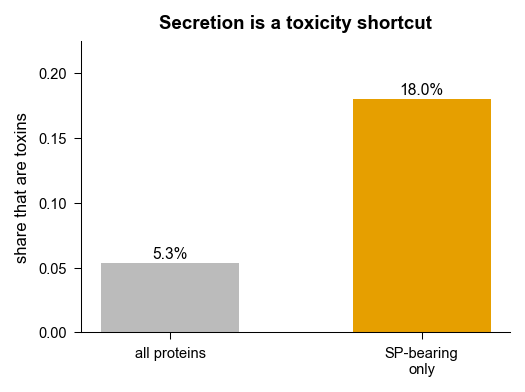


Used **alone** as a toxic/non-toxic classifier, "has a signal peptide" scores
precision 0.180 and recall 0.680, with an **odds ratio of
10.1x** -- it lifts toxin prevalence from 5.33% to
18.00% (3.4x) among the proteins it selects.

A single bit recovers 68% of all toxins and more than triples their
prevalence. It is a genuinely predictive feature, and a genuinely misleading one: it tracks
*secretion*, not *toxicity*. Most secreted proteins are not toxins (18%
precision), and a model leaning on it would fail exactly where it matters most -- on secreted
non-toxins such as the physiological phospholipases of SS4, every one of which carries a
signal peptide too. Trimming removes the shortcut before the model can see it, for *both*
classes, which also makes the binary head's `p_toxic` a statement about the mature protein
rather than about its trafficking signal.


In [20]:
sc = sp["shortcut"]
fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.5), layout="constrained")
ax.bar(["all proteins", "SP-bearing\nonly"], [sc["base_rate"], sc["lift_rate"]],
       color=[C_GREY, C_TOX], width=0.55)
for i, v in enumerate([sc["base_rate"], sc["lift_rate"]]):
    ax.text(i, v + 0.004, f"{v:.1%}", ha="center", fontsize=7.5)
ax.set_ylabel("share that are toxins")
ax.set_ylim(0, sc["lift_rate"] * 1.25)
ax.set_title("Secretion is a toxicity shortcut")
plt.show()

Markdown(f'''
Used **alone** as a toxic/non-toxic classifier, "has a signal peptide" scores
precision {sc['precision']:.3f} and recall {sc['recall']:.3f}, with an **odds ratio of
{sc['odds_ratio']:.1f}x** -- it lifts toxin prevalence from {sc['base_rate']:.2%} to
{sc['lift_rate']:.2%} ({sc['lift_factor']:.1f}x) among the proteins it selects.

A single bit recovers {sc['recall']:.0%} of all toxins and more than triples their
prevalence. It is a genuinely predictive feature, and a genuinely misleading one: it tracks
*secretion*, not *toxicity*. Most secreted proteins are not toxins ({sc['precision']:.0%}
precision), and a model leaning on it would fail exactly where it matters most -- on secreted
non-toxins such as the physiological phospholipases of SS4, every one of which carries a
signal peptide too. Trimming removes the shortcut before the model can see it, for *both*
classes, which also makes the binary head's `p_toxic` a statement about the mature protein
rather than about its trafficking signal.
''')

### 7.4 Is p>0.8 defensible? Check SignalP6 against UniProt's curated annotation

The 0.8 cutoff is stated without justification. It is checkable: the raw TSVs carry
UniProt's own curated `SIGNAL` feature, which is independent of SignalP6 and can serve as a
reference standard -- with the caveat that many UniProt signal-peptide annotations are
themselves sequence-analysis inferences (`ECO:0000255`) rather than experimental.

In [21]:
ct, cn, cl = sp["curation_toxins"], sp["curation_nontoxins"], sp["cleavage"]
display(pd.DataFrame({"toxins": ct, "non-toxins": cn}).T
        [["TP", "FP", "FN", "TN", "precision", "recall", "agreement"]]
        .style.format({"precision": "{:.3f}", "recall": "{:.3f}", "agreement": "{:.3f}"})
        .set_caption("SignalP6 (p > 0.8) vs UniProt's curated SIGNAL annotation"))

Markdown(f'''
**Verdict on decision 6: trimming is well justified -- better than the manuscript claims --
and the threshold is sound but should be reported with its one asymmetry.**

- The operating point is conservative and accurate: on toxins, p>0.8 reaches
  **{ct['precision']:.1%} precision and {ct['recall']:.1%} recall** against curation
  ({ct['agreement']:.1%} overall agreement), and lands the exact cleavage residue in
  **{cl['exact']:.0%}** of the {cl['n']:,} cases where both call a peptide
  ({cl['within_2']:.0%} within +/-2). This is a high-precision cutoff, and 0.8 can be
  defended as such rather than merely stated.
- The stated rationale is the weakest available one. Three real reasons sit behind it, and
  the manuscript makes none of them: SS7.2 (frame consistency, which matters *because* the
  model is embedding-based), SS7.1 (the block is ~a quarter of a typical toxin), and SS7.3
  (a {sc['odds_ratio']:.0f}x-odds secretion shortcut).
- **The one thing to disclose:** recall against curation is lower for non-toxins
  ({cn['recall']:.1%}) than for toxins ({ct['recall']:.1%}), leaving **{cn['FN']:,} curated
  non-toxin signal peptides untrimmed**. Trimming therefore *shrinks* the secretion confound
  rather than eliminating it, and the residue runs in the direction that flatters the model.
  Worth one sentence.
''')

,TP,FP,FN,TN,precision,recall,agreement
toxins,3748.000000,37.000000,45.000000,1737.000000,0.990,0.988,0.985
non-toxins,16941.000000,300.000000,1619.000000,79990.000000,0.983,0.913,0.981



**Verdict on decision 6: trimming is well justified -- better than the manuscript claims --
and the threshold is sound but should be reported with its one asymmetry.**

- The operating point is conservative and accurate: on toxins, p>0.8 reaches
  **99.0% precision and 98.8% recall** against curation
  (98.5% overall agreement), and lands the exact cleavage residue in
  **86%** of the 3,748 cases where both call a peptide
  (94% within +/-2). This is a high-precision cutoff, and 0.8 can be
  defended as such rather than merely stated.
- The stated rationale is the weakest available one. Three real reasons sit behind it, and
  the manuscript makes none of them: SS7.2 (frame consistency, which matters *because* the
  model is embedding-based), SS7.1 (the block is ~a quarter of a typical toxin), and SS7.3
  (a 10x-odds secretion shortcut).
- **The one thing to disclose:** recall against curation is lower for non-toxins
  (91.3%) than for toxins (98.8%), leaving **1,619 curated
  non-toxin signal peptides untrimmed**. Trimming therefore *shrinks* the secretion confound
  rather than eliminating it, and the residue runs in the direction that flatters the model.
  Worth one sentence.


## 8. Summary -- decision, evidence, verdict

Every number is interpolated from the audit result, so this table cannot drift from the
analysis above.

In [22]:
lo = R["summary"].iloc[0]
hi = R["summary"][np.isclose(R["summary"]["threshold"], PIPELINE_MIN_SEQ_ID)].iloc[0]
rows = [
    ("1. Lean 90% redundancy reduction",
     f"redundancy is concentrated - the {conc['top_n']} largest families supply "
     f"{conc['top_n_share']:.0%} of removals while {conc['zero_redundancy']} of "
     f"{conc['n_families']} toxin families have none; at min-seq-id {lo['threshold']:.1f} "
     f"only {int(lo['toxin_reps']):,} toxin reps survive and "
     f"{int(hi['families_kept']) - int(lo['families_kept'])} families fall below the "
     f"{MIN_MEMBERS}-rep floor",
     "JUSTIFIED - but by label-space preservation, not 'diversity'. Report the full MMseqs command."),
    ("2. Per-family clustering",
     f"{sf['n_shared']} family strings occur on both sides of KW-0800; {p['twins']} non-toxin "
     f"phospholipases are >={DUP_IDENT:.0%} identical to a toxin yet were clustered in a "
     f"different MMseqs run",
     "JUSTIFIED as a choice - cross-boundary dedup would prejudge the label. Must be stated in Methods."),
    ("3. Keyword-only toxic/non-toxic split",
     f"{nnb['with_nontoxin_homolog']:,}/{nnb['n_toxin_reps']:,} toxin reps have a non-toxin "
     f"homolog at >={DUP_COV:.0%} coverage; for {nnb['nearest_is_nontoxin']:,} "
     f"({nnb['nearest_is_nontoxin_frac']:.1%}) the NEAREST neighbour under HBI's own search "
     f"parameters is a non-toxin",
     "JUSTIFIED but consequential - the toxic/non-toxic boundary does not coincide with the "
     "homology boundary, giving best-hit transfer an irreducible error floor a learned model can get under."),
    ("4. Longest-1% non-toxin cut",
     f"ceiling {f['length_cutoff']:,} aa; removes {f['length_n_removed']:,} sequences "
     f"({f['length_residue_mass_removed']:.0%} of residue mass) without moving the median length",
     "DEFENSIBLE - restate as a length ceiling, not a percentile; 'dominating' is unsupported."),
    (f"5. <{MIN_MEMBERS}-member floor -> `other`",
     f"binds hardest under strict clustering: "
     f"{int(hi['families_kept']) - int(lo['families_kept'])} extra families dissolve at "
     f"min-seq-id {lo['threshold']:.1f}",
     "COUPLED to decision 1 - the two cannot be justified independently."),
    ("6. SignalP6 trimming at p>0.8",
     f"{sp['families_mixed']}/{sp['families_total']} toxin families are internally mixed "
     f"({sp['mixed_share']:.0%} of toxins); the SP is largely ignored by the aligner (medians "
     f"unchanged, but {fs['bits_changed_frac']:.0%} of per-query bit scores move; clustering "
     f"{spread['net_frac']:+.1%} net) yet is {sp['sp_frac_tox']:.0%} of a median toxin, which a "
     f"pooled embedding cannot skip; 'has an SP' alone predicts toxicity at "
     f"{sc['odds_ratio']:.0f}x odds; p>0.8 agrees with curation on {ct['agreement']:.0%} of toxins",
     "JUSTIFIED, and under-argued - the reason is embedding-specific. Disclose that non-toxin "
     "recall is lower, so the confound is shrunk, not removed."),
    ("Cost: residual train/test homology",
     f"{tth['ge70']}/{n_tox_test} = {tth['ge70_frac']:.0%} of toxin test reps have a >=70% "
     f"identical training neighbour; {tth['n_test_reps_ge90']} test reps exceed 90% "
     f"({tth['ge90_cross_family']} cross-family, all toxin<->non-toxin; {tth['ge90_same_family']} "
     f"same-family, which greedy set-cover clustering does not prevent)",
     "REPORT IT - reframe headline metrics as in-distribution; do NOT claim a hard 90% train/test ceiling."),
]
out = pd.DataFrame(rows, columns=["decision", "evidence measured here", "verdict"])
display(out.style.hide(axis="index")
        .set_properties(**{"text-align": "left", "vertical-align": "top"})
        .set_table_styles([{"selector": "td",
                            "props": [("max-width", "460px"), ("white-space", "normal")]}]))

path = write_numbers(N)
print(f"numbers written to {path}")

decision,evidence measured here,verdict
1. Lean 90% redundancy reduction,redundancy is concentrated - the 5 largest families supply 65% of removals while 4 of 44 toxin families have none; at min-seq-id 0.3 only 833 toxin reps survive and 20 families fall below the 10-rep floor,"JUSTIFIED - but by label-space preservation, not 'diversity'. Report the full MMseqs command."
2. Per-family clustering,85 family strings occur on both sides of KW-0800; 23 non-toxin phospholipases are >=90% identical to a toxin yet were clustered in a different MMseqs run,JUSTIFIED as a choice - cross-boundary dedup would prejudge the label. Must be stated in Methods.
3. Keyword-only toxic/non-toxic split,"1,446/3,416 toxin reps have a non-toxin homolog at >=80% coverage; for 300 (8.8%) the NEAREST neighbour under HBI's own search parameters is a non-toxin","JUSTIFIED but consequential - the toxic/non-toxic boundary does not coincide with the homology boundary, giving best-hit transfer an irreducible error floor a learned model can get under."
4. Longest-1% non-toxin cut,"ceiling 2,243 aa; removes 996 sequences (7% of residue mass) without moving the median length","DEFENSIBLE - restate as a length ceiling, not a percentile; 'dominating' is unsupported."
5. <10-member floor -> `other`,binds hardest under strict clustering: 20 extra families dissolve at min-seq-id 0.3,COUPLED to decision 1 - the two cannot be justified independently.
6. SignalP6 trimming at p>0.8,"29/44 toxin families are internally mixed (90% of toxins); the SP is largely ignored by the aligner (medians unchanged, but 30% of per-query bit scores move; clustering -1.3% net) yet is 24% of a median toxin, which a pooled embedding cannot skip; 'has an SP' alone predicts toxicity at 10x odds; p>0.8 agrees with curation on 99% of toxins","JUSTIFIED, and under-argued - the reason is embedding-specific. Disclose that non-toxin recall is lower, so the confound is shrunk, not removed."
Cost: residual train/test homology,"253/515 = 49% of toxin test reps have a >=70% identical training neighbour; 30 test reps exceed 90% (12 cross-family, all toxin<->non-toxin; 18 same-family, which greedy set-cover clustering does not prevent)",REPORT IT - reframe headline metrics as in-distribution; do NOT claim a hard 90% train/test ceiling.


numbers written to /Users/tsenoner/Documents/projects/ToxFam/paper/figures/output/preprocessing_numbers.json


## 9. What to change in the manuscript

In priority order, by how exposed each item is to a reviewer:

1. **Add the threshold ladder (SS2.2) to the supplement.** It converts *"90% preserves
   diversity"* from an assertion into the real argument: below ~70% the toxin label space
   itself starts dissolving. This is the single most challengeable claim in Methods, and the
   fix strengthens rather than weakens it.
2. **Add one Methods sentence on per-family clustering (SS3, SS4).** State that clustering is
   applied within each family, so the identity ceiling is never enforced across the
   toxic/non-toxic boundary, and give the phospholipase count as the worked example.
3. **Correct any implied train/test identity guarantee (SS6).** Claim what is true -- no
   member exceeds 90% identity to its cluster representative -- not a pairwise ceiling that
   greedy set-cover clustering does not provide.
4. **Publish the full MMseqs2 command.** Only `--min-seq-id 0.9` is currently stated;
   coverage, `--cov-mode` and cluster mode are omitted. As written, the clustering is not
   reproducible.
5. **Reframe the headline metrics as in-distribution (SS6)** and lean on `non_metazoan` and
   `unreviewed` as the generalisation evidence.
6. **Replace the signal-peptide rationale with the real ones (SS7).** Say that (a) at the
   observed trim rate the data would otherwise mix precursor and mature frames *within* most
   toxin families, and while an aligner largely skips the signal peptide, a pooled ProtT5
   embedding cannot; (b) signal-peptide presence is additionally a ~10x-odds toxicity
   shortcut tracking secretion rather than toxicity; and (c) p>0.8 is a high-precision
   operating point validated against UniProt's curated annotations. Disclose the lower
   non-toxin recall.
7. **Restate the length cut as a ceiling (SS1.1)** and **present the <10 floor together with
   the clustering threshold** rather than as independent choices.

The nearest-neighbour result in SS5 is the one finding that belongs in the *Discussion*
rather than Methods: it is the strongest available justification for the whole approach.

## 10. What this notebook does *not* show

Stated explicitly so the findings are not over-read:

- **No model was run.** Everything here is a property of the data and the preprocessing. The
  notebook shows that homology overlap exists and where it sits; it does not measure how much
  of any reported metric is attributable to it. Quantifying that needs an ablation -- retrain
  at a stricter threshold and compare -- which is out of scope and expensive (SS2.2 shows the
  label space changes, so the comparison is not like-for-like).
- **Identity is MMseqs2 `fident` over a local alignment**, not a global pairwise alignment.
  Marginal pairs near the 90% line are sensitive to that choice -- which is itself part of
  SS6.1's point.
- **The threshold ladder covers toxin families only.** The `nontox` bucket is not re-clustered
  at each threshold (it dominates runtime and its label space is a single class).
- **Signal-peptide trimming is motivated, not ablated.** SS7 shows *why* trimming is the right
  call and validates the 0.8 threshold against curated annotations. It does **not** show that a
  model trained on untrimmed sequences would perform worse, or would lean on the shortcut;
  that needs a with/without retraining comparison.
- **The embedding half of the frame argument is inferred, not measured.** SS7.2 shows directly
  that alignment is largely and clustering is nearly unaffected by the mixed frame, and argues
  from there that a pooled ProtT5 embedding must be the component that cares. That step is
  reasoning, not measurement: confirming it means embedding both variants and comparing
  within-family geometry, which this notebook does not do.
- **UniProt's `SIGNAL` annotation is not a gold standard.** Many entries are themselves
  sequence-analysis inferences (`ECO:0000255`), so SS7.4 measures agreement between two
  predictors that may share assumptions, not accuracy against truth.
- **The family normalisation map is not audited.** It is deterministic but hand-made; checking
  which merges were made is a separate task.
- **`other`-class composition after the second pass is not reported** -- how many sequences the
  post-clustering floor reassigns is a number the manuscript also omits.